# Tech Challenge Fase 3 — Avaliação e interpretação

Este notebook **não treina** de novo e **não escolhe** outro palpite. Ele só **abre o vestibular de 2024** do palpite que o notebook 03 já escolheu (regressão logística) e explica o resultado em português.


---

## Em uma frase

O palpite, olhando só região, estado, participação na prova e meta do estado, **quase não consegue dizer** quais municípios cumpriram a meta de alfabetização em 2024. Isso não é o código quebrado: é o limite do que restou de informação honesta (notebooks 01–03).

---

## De onde viemos

| Notebook | O que ficou decidido |
|---|---|
| **01** | Unidade = município + ano, não aluno. Norte/Nordeste abaixo da média. Várias colunas são a própria taxa (cola). |
| **02** | Alvo = taxa ≥ meta **de 2024**. Estudar em 2023, prova em 2024. |
| **03** | Ganhadora do simulado = **regressão logística**. Dummy F1 = 0. No 2024, acerto equilibrado ≈ 0,51. |
| **04 (este)** | Matriz de erros, curva ROC, *por que* o palpite chuta assim, erros por região. Sem trocar de modelo. |

---

## O que este notebook se recusa a fazer

- Treinar Random Forest “para comparar no teste”.
- Mexer no botão `C` porque a matriz de 2024 ficou feia.
- Recolocar taxa base / metas 2025–2029 / níveis 0–8 para “melhorar o gráfico”.

---

## Índice

1. Abrir o palpite e a prova de 2024
2. Números da prova (e o chute burro de 2024)
3. Matriz de confusão — onde acerta e onde erra
4. Curva ROC — melhor que cara-ou-coroa?
5. Pesos da reta — o que a logística usa
6. SHAP (opcional) — o mesmo recado, município a município
7. Erros por região — o palpite ainda pensa em 2023
8. Relatório final para copiar


## 1. Abrir o palpite e a prova de 2024

O arquivo `models/best_model.pkl` é a **logística + a receita de limpeza** que o notebook 03 gravou. `X_test` / `y_test` são os **5.232 municípios em 2024**.

A receita só usa seis colunas (região, UF, duas participações, meta de UF 2024, código da região). O parquet do notebook 02 ainda tem dezenas de colunas a mais; o tradutor **ignora** o resto. Mesmo assim, recortamos as seis para a análise de erros não virar uma planilha de 43 colunas.

**Não há aluno alfabetizado nesta avaliação.** Classe 1 = município **na meta** em 2024.


In [ ]:
import sys
from pathlib import Path
import importlib

ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import src.evaluation.metrics as metrics_mod
importlib.reload(metrics_mod)
from src.evaluation.metrics import ModelEvaluator
from src.preprocessing.data_preparation import HONEST_FEATURE_COLUMNS, load_or_prepare_split

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

model = joblib.load('../models/best_model.pkl')
X_train, X_test, y_train, y_test, preprocessor, groups_train, source = load_or_prepare_split(ROOT)
X_test = X_test[[c for c in HONEST_FEATURE_COLUMNS if c in X_test.columns]]

print('Fonte dos dados:', source)
print('Palpite:', type(model.named_steps['classifier']).__name__)
print('Botao C:', model.named_steps['classifier'].get_params().get('C'))
print('Lista canonica HONEST_FEATURE_COLUMNS:', list(HONEST_FEATURE_COLUMNS))
print('X_test (colunas honestas):', X_test.shape, list(X_test.columns))
print('Prova 2024 — fora da meta / na meta:')
print(y_test.value_counts(normalize=True).round(3).to_string())


- O classificador deve ser **LogisticRegression**, em geral com `C=0,1` (o botão que o Grid Search escolheu no simulado).
- **5.232** linhas no teste.
- Proporção ~**0,47 fora** / ~**0,53 na meta**. 



## 2. Números da prova — e o chute burro *deste* ano

No notebook 03 o Dummy do **simulado** chutava sempre “fora” (porque em 2023 isso era 82%). No **vestibular** de 2024 o chute burro muda: a resposta mais comum passou a ser “na meta” (53%).

Por isso comparamos o palpite com **dois chãos de 2024**:

| Chute burro em 2024 | Acurácia | F1 | Acerto equilibrado |
|---|---|---|---|
| Sempre “na meta” | ~53% | ~0,70 | **0,50** |
| Sempre “fora” | ~47% | 0 | **0,50** |

A coluna que não mente quando as duas turmas têm tamanho parecido é o **acerto equilibrado** (média do acerto em cada clube). 0,50 = cara-ou-coroa.


Gerando palpites no teste 2024...
   5,232 municípios.

METRICAS NO TESTE 2024 (municipio na meta de alfabetizacao)
   Acuracia              : 0.5036
   Acerto equilibrado    : 0.5127
   Precisao              : 0.5503
   Recall                : 0.3745
   F1                    : 0.4457
   ROC-AUC               : 0.5714

   Lembrete: acuracia ~0,50 e F1 ~0,45 perdem do chute "sempre na meta" (~53% / F1 ~0,70). O acerto equilibrado perto de 0,50 e a leitura honesta.

Comparacao na prova de 2024 (nao serve para TROCAR o palpite):
                    Palpite  Acuracia  Acerto equilibrado    F1  Precisao  Recall
Logistica (vencedora do 03)     0.504               0.513 0.446     0.550   0.374
 Burro 2024: sempre na meta     0.533               0.500 0.695     0.533   1.000
    Burro 2024: sempre fora     0.467               0.500 0.000     0.000   0.000


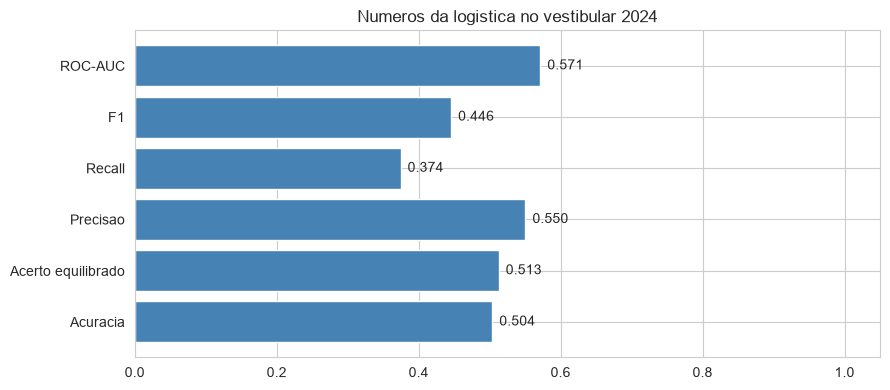

In [2]:
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    precision_score, recall_score,
)

evaluator = ModelEvaluator(model=model, X_test=X_test, y_test=y_test)
evaluator.calculate_metrics()

y_sempre1 = np.ones(len(y_test), dtype=int)
y_sempre0 = np.zeros(len(y_test), dtype=int)

def bloco(nome, yhat):
    return {
        'Palpite': nome,
        'Acuracia': accuracy_score(y_test, yhat),
        'Acerto equilibrado': balanced_accuracy_score(y_test, yhat),
        'F1': f1_score(y_test, yhat, zero_division=0),
        'Precisao': precision_score(y_test, yhat, zero_division=0),
        'Recall': recall_score(y_test, yhat, zero_division=0),
    }

yhat = model.predict(X_test)
cmp = pd.DataFrame([
    bloco('Logistica (vencedora do 03)', yhat),
    bloco('Burro 2024: sempre na meta', y_sempre1),
    bloco('Burro 2024: sempre fora', y_sempre0),
])
print('\nComparacao na prova de 2024 (nao serve para TROCAR o palpite):')
print(cmp.to_string(index=False, float_format=lambda x: f'{x:.3f}'))

fig, ax = plt.subplots(figsize=(9, 4))
mets = evaluator.get_metrics()
ax.barh(list(mets.keys()), list(mets.values()), color='steelblue')
ax.set_xlim(0, 1.05)
ax.set_title('Numeros da logistica no vestibular 2024')
for i, v in enumerate(mets.values()):
    ax.text(v + 0.01, i, f'{v:.3f}', va='center')
Path('../reports/figures').mkdir(parents=True, exist_ok=True)
plt.tight_layout()
plt.savefig('../reports/figures/evaluation_metrics.png', dpi=150, bbox_inches='tight')
plt.show()


### Como ler esses números (guia lento)

Valores típicos da logística nesta base:

| Métrica | Valor | Comparar com |
|---|---|---|
| Acerto equilibrado | **~0,51** | Cara-ou-coroa = 0,50. Quase não separa os dois grupos. |
| ROC-AUC | **~0,57** | Cara-ou-coroa = 0,50. Um pouco acima, sinal fraco. |
| F1 | ~0,45 | Chute sempre “na meta” ~**0,70**. |
| Acurácia | ~0,50 | Chute sempre “na meta” ~**0,53**. |
| Precisão | ~0,55 | A base já é 53% na meta: a lista quase não filtra. |
| Recall | ~0,37 | Encontra ~37% de quem cumpriu; perde os outros 63%. |

**Frase para o relatório:** *“Na prova de 2024 o palpite perde do chute sempre positivo em F1 e acurácia, e empata com o acaso no acerto equilibrado. Não é um classificador útil para política pública neste recorte.”*

Isso **não** autoriza voltar ao 03 para pegar a floresta. A floresta perdeu o simulado; o problema é o dado honesto, não o algoritmo.


## 3. Matriz de confusão — o placar em quatro caixas

Pense numa tabela 2×2. As linhas são a **verdade de 2024**. As colunas são o **palpite**.

|  | Palpite: fora | Palpite: na meta |
|---|---|---|
| **Era fora** | Acertou o “não” (TN) | Alarme falso (FP) — lista inflada |
| **Era na meta** | Deixou passar (FN) — o erro mais grave para “quem já cumpriu?” | Acertou o “sim” (TP) |

Números típicos (5.232 municípios):

- ~1.591 acertos “fora”
- ~853 alarmes falsos
- ~**1.744 deixou passar** (disse fora, mas a cidade cumpriu)
- ~1.044 acertos “na meta”

O palpite ainda se comporta um pouco como o mundo de 2023: **prefere dizer “fora”** (naquela época 82% estavam fora). Em 2024 isso gera uma pilha de municípios que cumpriram e foram classificados como fracasso.


Matriz salva em ../reports/figures/confusion_matrix.png


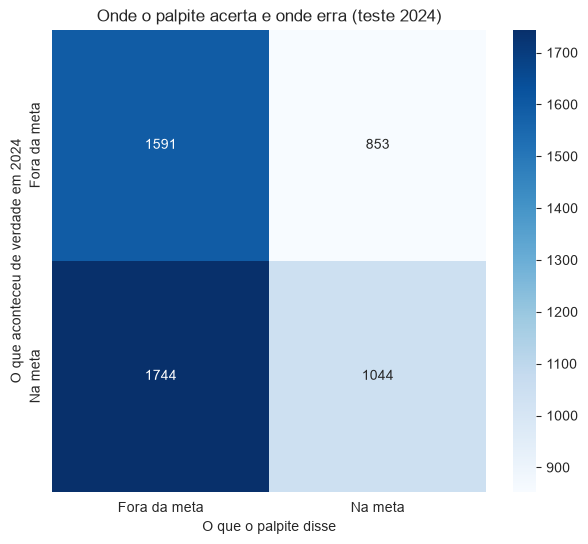


Leitura da matriz (5.232 municipios de 2024):
   Acertou "fora da meta" (TN):      1591
   Errou: disse na meta, era fora (FP):   853
   Errou: disse fora, era na meta (FN):  1744  <- o erro mais comum
   Acertou "na meta" (TP):           1044
   Acertos: 2635 (50.4%) | Erros: 2597 (49.6%)


In [3]:
evaluator.plot_confusion_matrix(save_path='../reports/figures/confusion_matrix.png')


### Como ler a matriz

Some a diagonal (acertos) e compare com a outra diagonal (erros). Quase **metade** dos municípios sai errada — condiz com acurácia ~50%.

O canto **embaixo à esquerda** (deixou passar) deve ser o retângulo mais gordo da classe “na meta”. Em português: o palpite **não reconhece o salto nacional de 2024**.


## 4. Curva ROC — o palpite é melhor que cara-ou-coroa?

A logística não chuta só 0 ou 1: ela dá uma **probabilidade** (“acho 30% que está na meta”). A curva ROC pergunta: se eu for abaixando a régua dessa probabilidade, consigo separar os dois grupos?

- A **diagonal** = alguém que sorteia.
- A **área sob a curva (AUC)**: 1,00 = perfeito; **0,50** = sorte; **abaixo de 0,50** = pior que sorte.

Aqui a área costuma ficar em **~0,57**: um fio acima da sorte. Confirma o acerto equilibrado de 0,51. Não há um limiar mágico (0,4, 0,6…) que transforme isso num bom classificador — a informação nas seis colunas não chega.


Curva ROC salva em ../reports/figures/roc_curve.png  |  area = 0.571


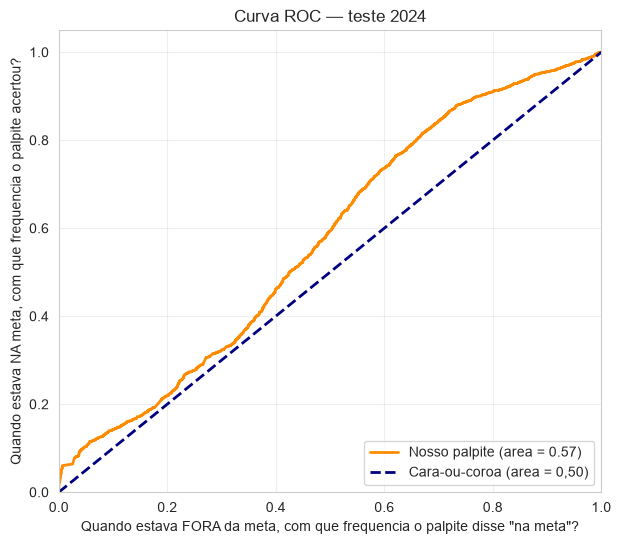

In [4]:
evaluator.plot_roc_curve(save_path='../reports/figures/roc_curve.png')


### Como ler a ROC

Se a linha laranja colar na diagonal, o palpite não ordena bem “quem tem mais chance de estar na meta”. Um pouco acima da diagonal = há um cheiro de padrão geográfico, insuficiente para a prova de 2024.

**Não** use a AUC de 0,57 para dizer que o modelo “está ok porque passou de 0,50”. Passou por um fio; o Dummy espacial da seção 7 mostra que o cheiro é o mapa de 2023, não o cumprimento da meta em 2024.


## 5. Pesos da reta — o que a logística “olha”

Árvores têm “importância de coluna”. A logística tem **pesos** (coeficientes):

- **Verde / positivo:** aquela informação puxa o palpite para “na meta”.
- **Vermelho / negativo:** puxa para “fora da meta”.
- O tamanho da barra = força do puxão (depois de colocar as colunas na mesma escala).

Estes pesos foram aprendidos no **caderno de 2023**. Por isso um estado que ia bem em 2023 continua “puxando para na meta” em 2024, mesmo que a barra e o país tenham mudado.

O peso mais estável costuma ser a **meta de alfabetização do estado em 2024** (contexto da UF) e a **participação** do município na prova. Vários nomes de UF aparecem porque cada estado virou uma coluna 0/1. Isso é o palpite **memorizando o mapa**, não medindo a taxa da cidade (a taxa foi proibida — era cola).



Maiores pesos (valor absoluto):
   num__meta_uf_alfabetizacao_2024                     +1.108  (na meta)
   cat__nome_uf_Pernambuco                             -0.956  (fora da meta)
   num__meta_municipio_percentual_participacao         +0.656  (na meta)
   cat__nome_uf_Paraná                                 -0.584  (fora da meta)
   cat__nome_uf_Maranhão                               +0.552  (na meta)
   cat__nome_uf_Rio Grande do Sul                      +0.543  (na meta)
   cat__nome_uf_Piauí                                  +0.504  (na meta)
   cat__nome_uf_São Paulo                              +0.427  (na meta)
   cat__nome_uf_Paraíba                                +0.406  (na meta)
   cat__nome_uf_Rio de Janeiro                         -0.392  (fora da meta)
   cat__regiao_Sudeste                                 -0.390  (fora da meta)
   cat__nome_uf_Bahia                                  -0.384  (fora da meta)
   cat__nome_uf_Santa Catarina                         +0.335  (na

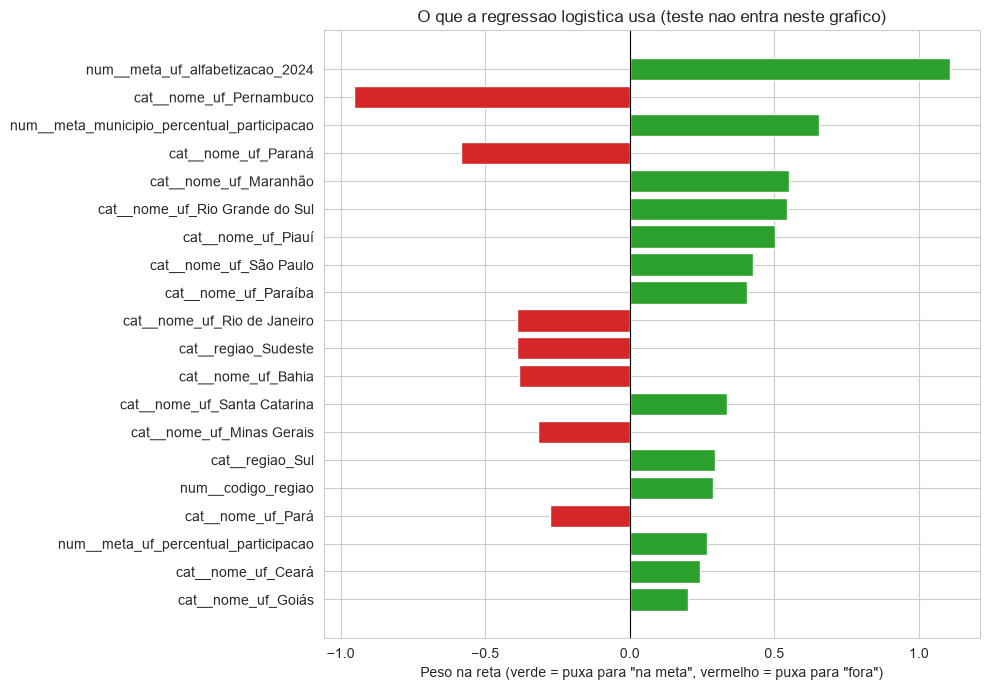

In [5]:
evaluator.plot_feature_importance(top_n=20, save_path='../reports/figures/feature_importance.png')


### Como ler as barras

Não leia “Pernambuco tem peso negativo” como “Pernambuco é o vilão da alfabetização”. Leia: *no caderno de 2023, depois de controlar as outras colunas, municípios daquela UF puxavam o palpite para fora da meta de 2024 — que na época era uma barra alta.*

A conclusão útil: o palpite é **um mapa de 2023 com um pouco de participação**. Não é um termômetro da taxa de 2024. Por isso a prova quebra.


## 6. SHAP (opcional) — o mesmo recado, cidade por cidade

SHAP tenta responder: “nesta cidade, o que empurrou o palpite para sim ou para não?”. Para a logística, isso é quase o peso × o valor da coluna. Se a biblioteca falhar, **os pesos da seção 5 já bastam** para o relatório.

Não usamos o explainer de árvore: o vencedor não é floresta.


Background dataset has 5232 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=5232 when initializing the masker.


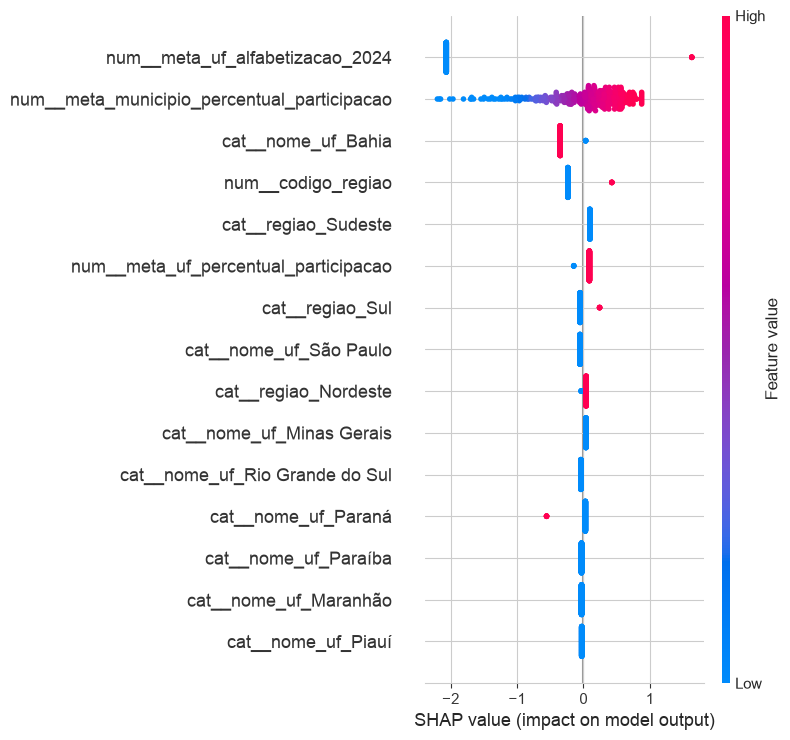

SHAP: cada ponto e um municipio. Vermelho = valor alto da coluna; para a direita empurra "na meta".


In [6]:
try:
    import shap
    pre = model.named_steps['preprocessor']
    clf = model.named_steps['classifier']
    X_trans = pre.transform(X_test)
    nomes = pre.get_feature_names_out()
    n = min(400, len(X_trans))
    explainer = shap.LinearExplainer(clf, X_trans)
    shap_values = explainer.shap_values(X_trans[:n])
    plt.figure(figsize=(10, 7))
    shap.summary_plot(shap_values, X_trans[:n], feature_names=nomes, show=False, max_display=15)
    plt.tight_layout()
    plt.savefig('../reports/figures/shap_summary.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('SHAP: cada ponto e um municipio. Vermelho = valor alto da coluna; para a direita empurra "na meta".')
except Exception as exc:
    print('SHAP indisponivel ou incompativel (', type(exc).__name__, '):', exc)
    print('Use o grafico de pesos da secao 5 no relatorio.')


## 7. Onde o palpite erra — ainda pensa em 2023

Se o erro fosse aleatório, todas as regiões errariam parecido. Se o palpite for um **mapa velho**, o erro muda de região: no Sul ele aponta “na meta” demais (lá isso era comum em 2023); no Norte quase nunca aponta; no Sudeste de 2024 muita gente cumpriu e ele não acredita.


Erros na prova de 2024
   Municipios:          5,232
   Erros:               2,597 (49.6%)
   Alarme falso (FP):   853  (disse na meta, era fora)
   Deixou passar (FN):  1,744  (disse fora, era na meta)

Por regiao (o palpite deveria acompanhar a coluna "real", nao a de 2023):
              municipios  pct_real_na_meta  pct_palpite_na_meta  pct_erro
regiao                                                                   
Centro-Oeste         461             0.731                0.540     0.399
Nordeste            1738             0.501                0.341     0.374
Norte                389             0.437                0.018     0.434
Sudeste             1590             0.662                0.160     0.587
Sul                 1054             0.339                0.752     0.626


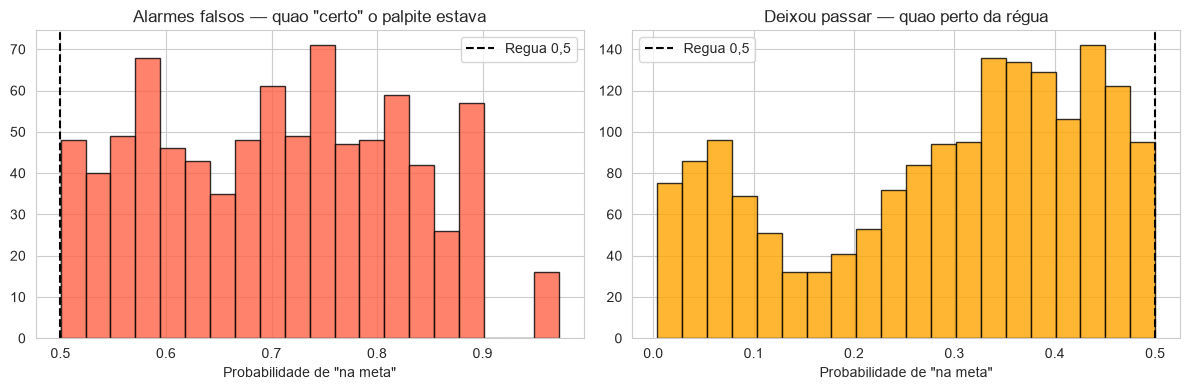

In [7]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

erros = X_test.copy()
erros['verdade'] = y_test.values
erros['palpite'] = y_pred
erros['probabilidade'] = y_proba
erros['errou'] = (erros['verdade'] != erros['palpite']).astype(int)
fp = erros[(erros['verdade'] == 0) & (erros['palpite'] == 1)]
fn = erros[(erros['verdade'] == 1) & (erros['palpite'] == 0)]

print('Erros na prova de 2024')
print(f'   Municipios:          {len(erros):,}')
print(f'   Erros:               {erros["errou"].sum():,} ({erros["errou"].mean():.1%})')
print(f'   Alarme falso (FP):   {len(fp):,}  (disse na meta, era fora)')
print(f'   Deixou passar (FN):  {len(fn):,}  (disse fora, era na meta)')

por_regiao = (
    erros.groupby('regiao')
    .agg(
        municipios=('errou', 'size'),
        pct_real_na_meta=('verdade', 'mean'),
        pct_palpite_na_meta=('palpite', 'mean'),
        pct_erro=('errou', 'mean'),
    )
    .round(3)
)
print('\nPor regiao (o palpite deveria acompanhar a coluna "real", nao a de 2023):')
print(por_regiao.to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
if len(fp):
    axes[0].hist(fp['probabilidade'], bins=20, color='tomato', edgecolor='black', alpha=0.8)
axes[0].axvline(0.5, color='black', ls='--', label='Regua 0,5')
axes[0].legend()
axes[0].set_title('Alarmes falsos — quao "certo" o palpite estava')
axes[0].set_xlabel('Probabilidade de "na meta"')
if len(fn):
    axes[1].hist(fn['probabilidade'], bins=20, color='orange', edgecolor='black', alpha=0.8)
axes[1].axvline(0.5, color='black', ls='--', label='Regua 0,5')
axes[1].legend()
axes[1].set_title('Deixou passar — quao perto da régua')
axes[1].set_xlabel('Probabilidade de "na meta"')
plt.tight_layout()
plt.savefig('../reports/figures/error_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


### Como ler os erros por região

Na tabela, compare **pct_real_na_meta** (o que 2024 fez) com **pct_palpite_na_meta** (o que o mapa de 2023 chutou):

- **Sul:** o palpite aponta “na meta” **muito mais** do que 2024 cumpriu — eco de 2023.
- **Norte:** o palpite quase **nunca** aponta “na meta”, mesmo com dezenas de municípios cumprindo.
- **Sudeste:** em 2024 a maior parte cumpriu; o palpite continua pessimista.

Os histogramas da probabilidade: se os “deixou passar” se acumulam **logo abaixo de 0,5**, o palpite estava em dúvida e a régua fixa de 50% (herdada do treino desbalanceado) empurrou para “fora”. **Não** abaixe essa régua agora só porque viu o histograma — isso seria tunar no vestibular. Fica como lição: em 2023 a régua 50% + peso nas classes raras ainda assim prefere o “fora”.

**Frase para o relatório:** *“Os erros não são aleatórios: repetem o mapa de 2023. Geografia é contexto legítimo, mas não antecipa o salto nacional da taxa em 2024.”*


## 8. Relatório final

A célula abaixo grava o relatório técnico (precisão/recall por classe). O texto longo é o que entra na dissertação.


In [8]:
evaluator.generate_classification_report(save_path='../reports/classification_report.txt')



              precision    recall  f1-score   support

Fora da meta     0.4771    0.6510    0.5506      2444
     Na meta     0.5503    0.3745    0.4457      2788

    accuracy                         0.5036      5232
   macro avg     0.5137    0.5127    0.4981      5232
weighted avg     0.5161    0.5036    0.4947      5232

Relatorio salvo em ../reports/classification_report.txt


### Performance na prova de 2024

- **Palpite:** regressão logística (`C=0,1`, pesos balanceados), escolhida por F1 no simulado de 2023.
- **Acerto equilibrado ≈ 0,51** | **ROC-AUC ≈ 0,57** | **F1 ≈ 0,45** | **Acurácia ≈ 0,50**
- Perde do chute “sempre na meta” em F1 (~0,70) e acurácia (~0,53).
- Matriz: o erro dominante é **deixar passar** quem já estava na meta (~1.744 municípios).

### O que o palpite realmente usa

- Meta de UF 2024, participação na prova e **bandeiras de estado/região** (mapa de 2023).
- Não usa taxa, média de português, taxa base, níveis 0–8 nem a rampa de metas municipais — isso seria cola (notebooks 01–03).

### Limitações (não são “faltou XGBoost”)

1. Classificar “na meta neste mesmo ano” **sem a taxa do ano** é quase prever o resultado sem o resultado.
2. A barra é a meta de 2024 para os dois anos: em 2023 “na meta” era raro; em 2024 virou maioria. O palpite estudou o primeiro mundo.
3. Seis colunas honestas não carregam o salto de ~3 pontos na taxa nacional.
4. Não há aluno neste Silver; não há corte 743.

### O que *melhoraria* o trabalho (desenho, não biblioteca)

- **Notebook 05:** taxa de 2023 → taxa de 2024 (regressão lag-1), e só então comparar a taxa prevista com a meta já conhecida.
- Cruzar IDHM, Censo Escolar, IDEB por `id_municipio`.
- **Não** recolocar cola para inflar F1.

### Frases prontas

1. *“A avaliação usa só o palpite escolhido em 2023; o teste de 2024 não reabre a escolha.”*
2. *“O acerto equilibrado de 0,51 indica que o classificador não separa municípios na meta.”*
3. *“A matriz e os erros por região mostram um mapa de 2023, não o cumprimento da meta em 2024.”*
4. *“O valor da Fase 3 é o protocolo (backtest, vazamento, F1 no treino desbalanceado), não um modelo de produção.”*

---

Fase 3, neste recorte de dados, está **completa e honesta**: EDA, preparação, modelagem com prova no futuro, e interpretação que admite o limite do Silver municipal.
